<a href="https://colab.research.google.com/github/same-57/rovproject/blob/main/Copy_of_FishialRUNNER.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import sys
import copy
import random
import json
import yaml
import glob
import cv2
import numpy as np
import time
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import requests
from   zipfile import ZipFile
%matplotlib inline
import pandas as pd
import logging
import torch

# Set up logging
logging.basicConfig(level=logging.INFO)

ImportError: cannot import name 'ZipFilezzz' from 'zipfile' (/usr/lib/python3.12/zipfile/__init__.py)

In [ ]:
def download_and_unzip(url, save_path, extract_dir):
    print("Downloading assets...")
    file = requests.get(url)

    open(save_path, "wb").write(file.content)
    print("Download completed.")

    try:
        if save_path.endswith(".zip"):
            with ZipFile(save_path, 'r') as zip_ref:
                zip_ref.extractall(extract_dir)
            print("Extraction Done")
    except Exception as e:
        print(f"An error occurred: {e}")

def download_image(url):
    filename = os.path.basename(url)

    response = requests.get(url)
    response.raise_for_status()

    with open(filename, 'wb') as file:
        file.write(response.content)

    return os.path.abspath(filename)

def get_basename(path):
  return os.path.basename(path)

def print_fish_data(fish_data):
    for idx, fish in enumerate(fish_data, start=1):
        print(f"ID: {idx}")
        print(f"Name: {fish['name']}")
        print(f"Species ID: {fish['species_id']}")
        print(f"Distance: {fish['distance']:.3f}")
        print(f"Accuracy: {fish['accuracy']:.2%}")
        print("-" * 40)


In [ ]:
# Links to models
MODEL_URLS = {
    'classification': 'https://storage.googleapis.com/fishial-ml-resources/classification_rectangle_v7-1.zip',
    'segmentation': 'https://storage.googleapis.com/fishial-ml-resources/segmentator_fpn_res18_416_1.zip',
    'detection': 'https://storage.googleapis.com/fishial-ml-resources/detector_v10_m3.zip',
    'face': 'https://storage.googleapis.com/fishial-ml-resources/face_yolo.zip'
}

# Model directories
MODEL_DIRS = {
    'classification': "models/classification",
    'segmentation': "models/segmentation",
    'detection': "models/detection",
    'face': "models/face_detector"
}

# Create directories and download models
for model_name, url in MODEL_URLS.items():
    model_dir = MODEL_DIRS[model_name]
    zip_path = os.path.join(os.getcwd(), get_basename(url))

    os.makedirs(model_dir, exist_ok=True)  # Create directory if it doesn't exist
    download_and_unzip(url, zip_path, model_dir)  # Download and unzip the model

    # Remove the zip file after extraction
    try:
        os.remove(zip_path)
        logging.info(f"Removed zip file {zip_path}")
    except Exception as e:
        logging.error(f"Failed to remove zip file {zip_path}: {e}")

Download completed.
An error occurred: name 'ZipFile' is not defined


NameError: name 'logging' is not defined

In [ ]:
from models.classification.inference import EmbeddingClassifier
from models.detection.inference import YOLOInference
from models.segmentation.inference import Inference
from models.face_detector.inference import YOLOInference as FaceInference
#machine learning models (there might be better classification models that fits)


# Model initialization
classifier = EmbeddingClassifier(
    os.path.join(MODEL_DIRS['classification'], 'model.ts'),
    os.path.join(MODEL_DIRS['classification'], 'database.pt')
)

segmentator = Inference(
    model_path=os.path.join(MODEL_DIRS['segmentation'], 'model.ts'),
    image_size=416
)

detector = YOLOInference(
    os.path.join(MODEL_DIRS['detection'], 'model.ts'),
    imsz=(640, 640),
    conf_threshold=0.9,
    nms_threshold=0.3,
    yolo_ver='v10'
)

In [ ]:
# You can change link below to your image with fish
from google.colab import files
# JUST A HEADS UP, you MUST GO TO THE FOLLOWING WEBSITES TO USE THESE FILES!
#url_face = 'https://www.online-tech-tips.com/wp-content/uploads/2022/02/faces.jpeg'
#url = 'https://www.mdpi.com/fishes/fishes-08-00514/article_deploy/html/images/fishes-08-00514-g001.png'
# and then rename downloaded files to the names below. or use your own local
# files


result = files.upload()
fish_path = list(result.keys())[0]
# face_path = "faces.webp"

Saving download.jfif to download.jfif


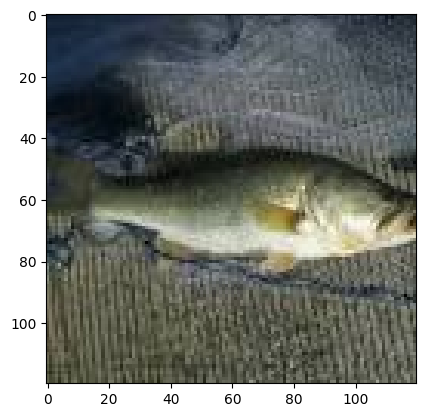

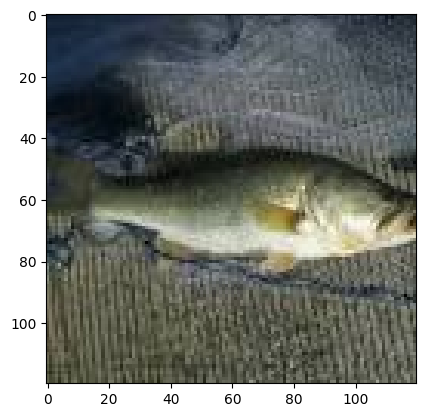

In [ ]:
fish_bgr_np = cv2.imread(fish_path)
visulize_img_bgr = fish_bgr_np.copy()

visulize_img_rgb = cv2.cvtColor(fish_bgr_np, cv2.COLOR_BGR2RGB)
visulize_img = copy.deepcopy(visulize_img_rgb)

face_boxes = face_detector.predict(visulize_img_rgb)[0]

for box in face_boxes:
  box.draw_label(visulize_img, "Face")
  box.draw_box(visulize_img)
plt.imshow(visulize_img)
plt.show()

boxes = detector.predict(visulize_img_rgb)[0]

for box in boxes:
  cropped_fish_bgr = box.get_mask_BGR()
  cropped_fish_rgb = box.get_mask_RGB()
  segmented_polygons = segmentator.predict(cropped_fish_bgr)[0]

  croped_fish_mask = segmented_polygons.mask_polygon(cropped_fish_rgb)

  segmented_polygons.move_to(box.x1, box.y1)
  segmented_polygons.draw_polygon(visulize_img)

  classification_result = classifier.batch_inference([cropped_fish_bgr])[0]

  label = f"{classification_result[0]['name']} | {round(classification_result[0]['accuracy'], 3)}" if len(classification_result) else "Not Found"
  box.draw_label(visulize_img, label)
  box.draw_box(visulize_img)

  print(50 * "=")
  plt.imshow(croped_fish_mask)
  plt.show()
  print_fish_data(classification_result)
plt.imshow(visulize_img)
plt.show()

# FU

In [ ]:
import time
import cv2

# Image Load

fish_bgr_np = cv2.imread(fish_path)
fish_rgb_np = cv2.cvtColor(fish_bgr_np, cv2.COLOR_BGR2RGB)

times_array = []
for _ in range(3):
  start_time_complex = time.time()
  # print(20 * "=")
  # start_time = time.time()
  # face_boxes = face_detector.predict(face_bgr_np)[0]
  # end_time = time.time()
  # print(f"Face detection time: {end_time - start_time:.4f} seconds")

  start_time = time.time()
  boxes = detector.predict(fish_bgr_np)[0]
  end_time = time.time()
  print(f"Fish detection time: {end_time - start_time:.4f} seconds")

  # Обработка каждого объекта
  for box in boxes:
      cropped_fish_bgr = box.get_mask_BGR()

      # Segmentation
      start_time = time.time()
      segmented_polygons = segmentator.predict(cropped_fish_bgr)[0]
      end_time = time.time()
      print(f"Segmentation time: {end_time - start_time:.4f} seconds")

      # Classification
      start_time = time.time()
      classification_result = classifier.batch_inference([cropped_fish_bgr])[0]
      end_time = time.time()
      print(f"Classification time: {end_time - start_time:.4f} seconds")
  times_array.append(time.time() - start_time_complex)

print(f"Average time: {sum(times_array)/len(times_array)}")

Fish detection time: 0.4235 seconds
Fish detection time: 0.3407 seconds
Fish detection time: 0.3363 seconds
Average time: 0.36694860458374023


## Face detection time execution test without postprocessing

In [ ]:
#Face detection is slower since it's more complex

BATCH_SIZE = 10
start_time = time.time()
face_detector.model(torch.randn(BATCH_SIZE,3,640,640))
print(f"Mean face detection total time (Batch): {(time.time() - start_time)} seconds")

Mean face detection total time (Batch): 1.4649295806884766 seconds


## Fish detection time execution test without postprocessing

In [ ]:
#Fish detection time is faster

BATCH_SIZE = 1
start_time = time.time()
detector.model(torch.randn(BATCH_SIZE,3,640,640))
print(f"Mean fish detection total time (Batch): {(time.time() - start_time)} seconds")


Mean fish detection total time (Batch): 0.34392476081848145 seconds


## Fish Segmentation time execution test without postprocessing

In [ ]:
BATCH_SIZE = 5
start_time = time.time()
segmentator.model(torch.randn(BATCH_SIZE,3,416,416))
print(f"Fish segmentation total time (Batch): {(time.time() - start_time)} seconds")

NameError: name 'time' is not defined

## Fish Classification time execution test without postprocessing

In [ ]:
BATCH_SIZE = 5
start_time = time.time()
classifier.model(torch.randn(BATCH_SIZE,3,224,224))
print(f"Fish Classification total time (Batch): {(time.time() - start_time)} seconds")